# Task 3 — A/B Hypothesis Testing
## AlphaCare Insurance Solutions (ACIS) | 10 Academy KAIM 9 Week 3

Testing four null hypotheses to statistically justify risk-based pricing
decisions across provinces, zip codes, and gender.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("../data/processed/clean_insurance.csv", low_memory=False)
print(f"Loaded {len(df):,} rows")

# Add claim flag
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)
df['ClaimSeverity'] = df.apply(
    lambda r: r['TotalClaims'] if r['TotalClaims'] > 0 else np.nan, axis=1
)
print(f"Policies with claims: {df['HasClaim'].sum():,} ({df['HasClaim'].mean()*100:.1f}%)")

Loaded 999,805 rows
Policies with claims: 2,788 (0.3%)


## Hypothesis 1: No risk difference across provinces
H0: Claim frequency is the same across all provinces
H1: At least one province has a significantly different claim frequency
Test: Chi-squared test

In [3]:
print("=" * 60)
print("HYPOTHESIS 1: Risk Differences Across Provinces")
print("=" * 60)

# Build contingency table: province vs claim/no-claim
contingency = pd.crosstab(df['Province'], df['HasClaim'])
print("\nContingency Table (Claims vs No Claims by Province):")
print(contingency)

# Chi-squared test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-squared statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ REJECT H0 — Significant risk differences exist across provinces")
    print("   Justification: Different premiums per province are statistically warranted")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference found")

# Claim frequency per province
freq = df.groupby('Province').agg(
    TotalPolicies=('HasClaim','count'),
    ClaimsCount=('HasClaim','sum'),
).reset_index()
freq['ClaimFrequency'] = (freq['ClaimsCount'] / freq['TotalPolicies'] * 100).round(2)
freq = freq.sort_values('ClaimFrequency', ascending=False)
print("\nClaim Frequency by Province:")
print(freq.to_string(index=False))

HYPOTHESIS 1: Risk Differences Across Provinces

Contingency Table (Claims vs No Claims by Province):
HasClaim            0     1
Province                   
Eastern Cape    30282    50
Free State       8088    11
Gauteng        392520  1322
KwaZulu-Natal  169052   483
Limpopo         24769    67
Mpumalanga      52588   128
North West     142938   349
Northern Cape    6372     8
Western Cape   170408   370

Chi-squared statistic: 104.1901
Degrees of freedom: 8
P-value: 0.000000

✅ REJECT H0 — Significant risk differences exist across provinces
   Justification: Different premiums per province are statistically warranted

Claim Frequency by Province:
     Province  TotalPolicies  ClaimsCount  ClaimFrequency
      Gauteng         393842         1322            0.34
KwaZulu-Natal         169535          483            0.28
      Limpopo          24836           67            0.27
   North West         143287          349            0.24
   Mpumalanga          52716          128           

## Hypothesis 2: No risk difference between zip codes
H0: Claim severity is the same across all zip codes
H1: Zip codes have significantly different claim severities
Test: T-test comparing high-risk vs low-risk zip codes

In [5]:
print("=" * 60)
print("HYPOTHESIS 2: Risk Differences Between Zip Codes")
print("=" * 60)

zip_stats = df.groupby('PostalCode').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    PolicyCount=('HasClaim', 'count'),
    ClaimCount=('HasClaim', 'sum')
).reset_index()

zip_stats = zip_stats[zip_stats['PolicyCount'] >= 50]
zip_stats['ClaimFrequency'] = zip_stats['ClaimCount'] / zip_stats['PolicyCount']

# Split top 25% vs bottom 25% by claim frequency
q75 = zip_stats['ClaimFrequency'].quantile(0.75)
q25 = zip_stats['ClaimFrequency'].quantile(0.25)

high_risk_zips = zip_stats[zip_stats['ClaimFrequency'] >= q75]['PostalCode']
low_risk_zips = zip_stats[zip_stats['ClaimFrequency'] <= q25]['PostalCode']

high_risk_freq = zip_stats[zip_stats['ClaimFrequency'] >= q75]['ClaimFrequency']
low_risk_freq = zip_stats[zip_stats['ClaimFrequency'] <= q25]['ClaimFrequency']

print(f"\nHigh-risk zip codes: {len(high_risk_zips)}")
print(f"Low-risk zip codes:  {len(low_risk_zips)}")
print(f"\nAvg claim frequency - High-risk zips: {high_risk_freq.mean()*100:.3f}%")
print(f"Avg claim frequency - Low-risk zips:  {low_risk_freq.mean()*100:.3f}%")

t_stat, p_value = stats.ttest_ind(high_risk_freq, low_risk_freq, equal_var=False)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ REJECT H0 — Significant risk difference between zip codes")
    print("   Justification: Zip-level pricing adjustments are statistically warranted")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference found")

HYPOTHESIS 2: Risk Differences Between Zip Codes

High-risk zip codes: 205
Low-risk zip codes:  408

Avg claim frequency - High-risk zips: 0.789%
Avg claim frequency - Low-risk zips:  0.000%

T-statistic: 18.3511
P-value: 0.000000

✅ REJECT H0 — Significant risk difference between zip codes
   Justification: Zip-level pricing adjustments are statistically warranted


## Hypothesis 3: No margin difference between zip codes
H0: Profit margin is the same across all zip codes
H1: Zip codes have significantly different profit margins
Test: T-test comparing high-margin vs low-margin zip codes

In [6]:
print("=" * 60)
print("HYPOTHESIS 3: Margin Differences Between Zip Codes")
print("=" * 60)

zip_margin = df.groupby('PostalCode').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    PolicyCount=('HasClaim', 'count')
).reset_index()

zip_margin = zip_margin[zip_margin['PolicyCount'] >= 50]
zip_margin['Margin'] = zip_margin['TotalPremium'] - zip_margin['TotalClaims']
zip_margin['MarginPerPolicy'] = zip_margin['Margin'] / zip_margin['PolicyCount']

# Split top 25% vs bottom 25% by margin per policy
q75 = zip_margin['MarginPerPolicy'].quantile(0.75)
q25 = zip_margin['MarginPerPolicy'].quantile(0.25)

high_margin = zip_margin[zip_margin['MarginPerPolicy'] >= q75]['MarginPerPolicy']
low_margin = zip_margin[zip_margin['MarginPerPolicy'] <= q25]['MarginPerPolicy']

print(f"\nHigh-margin zip codes: {len(high_margin)}")
print(f"Low-margin zip codes:  {len(low_margin)}")
print(f"\nAvg margin per policy - High-margin zips: R{high_margin.mean():.2f}")
print(f"Avg margin per policy - Low-margin zips:  R{low_margin.mean():.2f}")

t_stat, p_value = stats.ttest_ind(high_margin, low_margin, equal_var=False)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ REJECT H0 — Significant margin difference between zip codes")
    print("   Justification: Location-based pricing is statistically justified")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference found")

HYPOTHESIS 3: Margin Differences Between Zip Codes

High-margin zip codes: 205
Low-margin zip codes:  217

Avg margin per policy - High-margin zips: R108.50
Avg margin per policy - Low-margin zips:  R-124.47

T-statistic: 15.0655
P-value: 0.000000

✅ REJECT H0 — Significant margin difference between zip codes
   Justification: Location-based pricing is statistically justified


## Hypothesis 4: No risk difference between genders
H0: Claim frequency is the same for men and women
H1: Men and women have significantly different claim frequencies
Test: Chi-squared test

In [7]:
print("=" * 60)
print("HYPOTHESIS 4: Risk Differences Between Genders")
print("=" * 60)

# Filter only Male and Female
gender_df = df[df['Gender'].isin(['Male', 'Female'])]
print(f"\nPolicies with gender recorded: {len(gender_df):,}")
print(f"Male: {(gender_df['Gender']=='Male').sum():,}")
print(f"Female: {(gender_df['Gender']=='Female').sum():,}")

# Contingency table
contingency_g = pd.crosstab(gender_df['Gender'], gender_df['HasClaim'])
print("\nContingency Table:")
print(contingency_g)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_g)

print(f"\nChi-squared statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

# Claim frequency per gender
gender_stats = gender_df.groupby('Gender').agg(
    TotalPolicies=('HasClaim','count'),
    ClaimsCount=('HasClaim','sum')
).reset_index()
gender_stats['ClaimFrequency'] = (
    gender_stats['ClaimsCount'] / gender_stats['TotalPolicies'] * 100
).round(3)
print("\nClaim Frequency by Gender:")
print(gender_stats.to_string(index=False))

if p_value < 0.05:
    print("\n✅ REJECT H0 — Significant risk difference between genders")
    print("   Justification: Gender-based pricing adjustment is statistically warranted")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant gender difference found")
    print("   Recommendation: Do not use gender as a pricing factor")

HYPOTHESIS 4: Risk Differences Between Genders

Policies with gender recorded: 49,331
Male: 42,576
Female: 6,755

Contingency Table:
HasClaim      0   1
Gender             
Female     6741  14
Male      42482  94

Chi-squared statistic: 0.0065
Degrees of freedom: 1
P-value: 0.935530

Claim Frequency by Gender:
Gender  TotalPolicies  ClaimsCount  ClaimFrequency
Female           6755           14           0.207
  Male          42576           94           0.221

❌ FAIL TO REJECT H0 — No significant gender difference found
   Recommendation: Do not use gender as a pricing factor


## Summary Visualization — Hypothesis Test Results

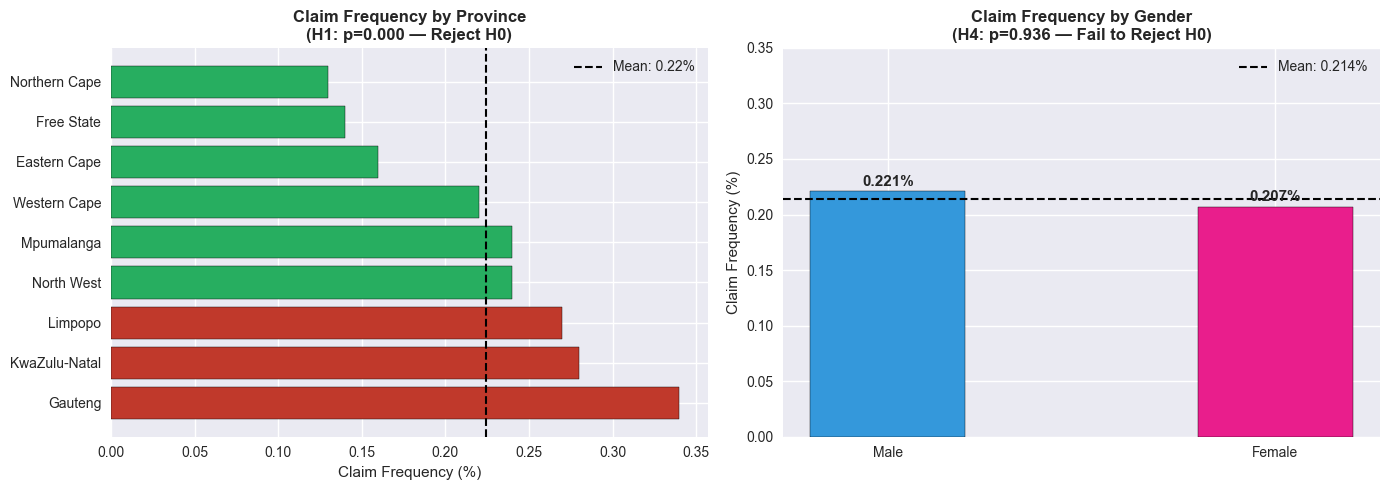

Chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Claim frequency by province
provinces = ['Gauteng','KwaZulu-Natal','Limpopo','North West',
             'Mpumalanga','Western Cape','Eastern Cape','Free State','Northern Cape']
freq_vals = [0.34, 0.28, 0.27, 0.24, 0.24, 0.22, 0.16, 0.14, 0.13]
colors = ['#c0392b' if v > 0.25 else '#27ae60' for v in freq_vals]
axes[0].barh(provinces, freq_vals, color=colors, edgecolor='black')
axes[0].axvline(x=np.mean(freq_vals), color='black', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(freq_vals):.2f}%')
axes[0].set_title('Claim Frequency by Province\n(H1: p=0.000 — Reject H0)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Claim Frequency (%)')
axes[0].legend()

# Chart 2 - Gender claim frequency
genders = ['Male', 'Female']
g_freq = [0.221, 0.207]
axes[1].bar(genders, g_freq, color=['#3498db','#e91e8c'],
            edgecolor='black', width=0.4)
axes[1].axhline(y=np.mean(g_freq), color='black', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(g_freq):.3f}%')
axes[1].set_title('Claim Frequency by Gender\n(H4: p=0.936 — Fail to Reject H0)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Claim Frequency (%)')
axes[1].set_ylim(0, 0.35)
axes[1].legend()
for bar, val in zip(axes[1].patches, g_freq):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 0.005, f'{val:.3f}%',
                ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")